In [4]:
import imageio.v3 as iio
import matplotlib.pyplot as plt
from pathlib import Path 
import glob, os
import numpy as np
from motionnet.dataset.van_hateren_utils import load_vanhateren_raw, log_image, random_crop
from motionnet.dataset import GetNaturalMovies, animate_sample, plot_examples
from scipy.ndimage import uniform_filter, spline_filter, map_coordinates
from tqdm import tqdm
import seaborn as sns
sns.set_context("talk")

In [ ]:
## GLOBAL VARS
N_IMAGES = 30
RNG = np.random.default_rng(0)
DATA_PATH = Path("/home/guardomayas/NUIN/van_hateren/vanhateren_iml")
DPP = 1/60 # Van Hateren images are 1/60 deg per pixel 

# 1. Self contained notebook to illustrate how to make Van Hateren Dataset fly like

In [6]:
iml_files = np.array(sorted(DATA_PATH.glob("*.iml")), dtype=object)
selected_files = iml_files[RNG.choice(len(iml_files), size=N_IMAGES, replace=False)]

images = np.empty((N_IMAGES, 1024, 1536), dtype=np.float32)

for i, f in enumerate(tqdm(selected_files, desc="Loading images")):
    img = log_image(f)
    images[i] = img    

Loading images: 100%|██████████| 100/100 [00:01<00:00, 87.24it/s]


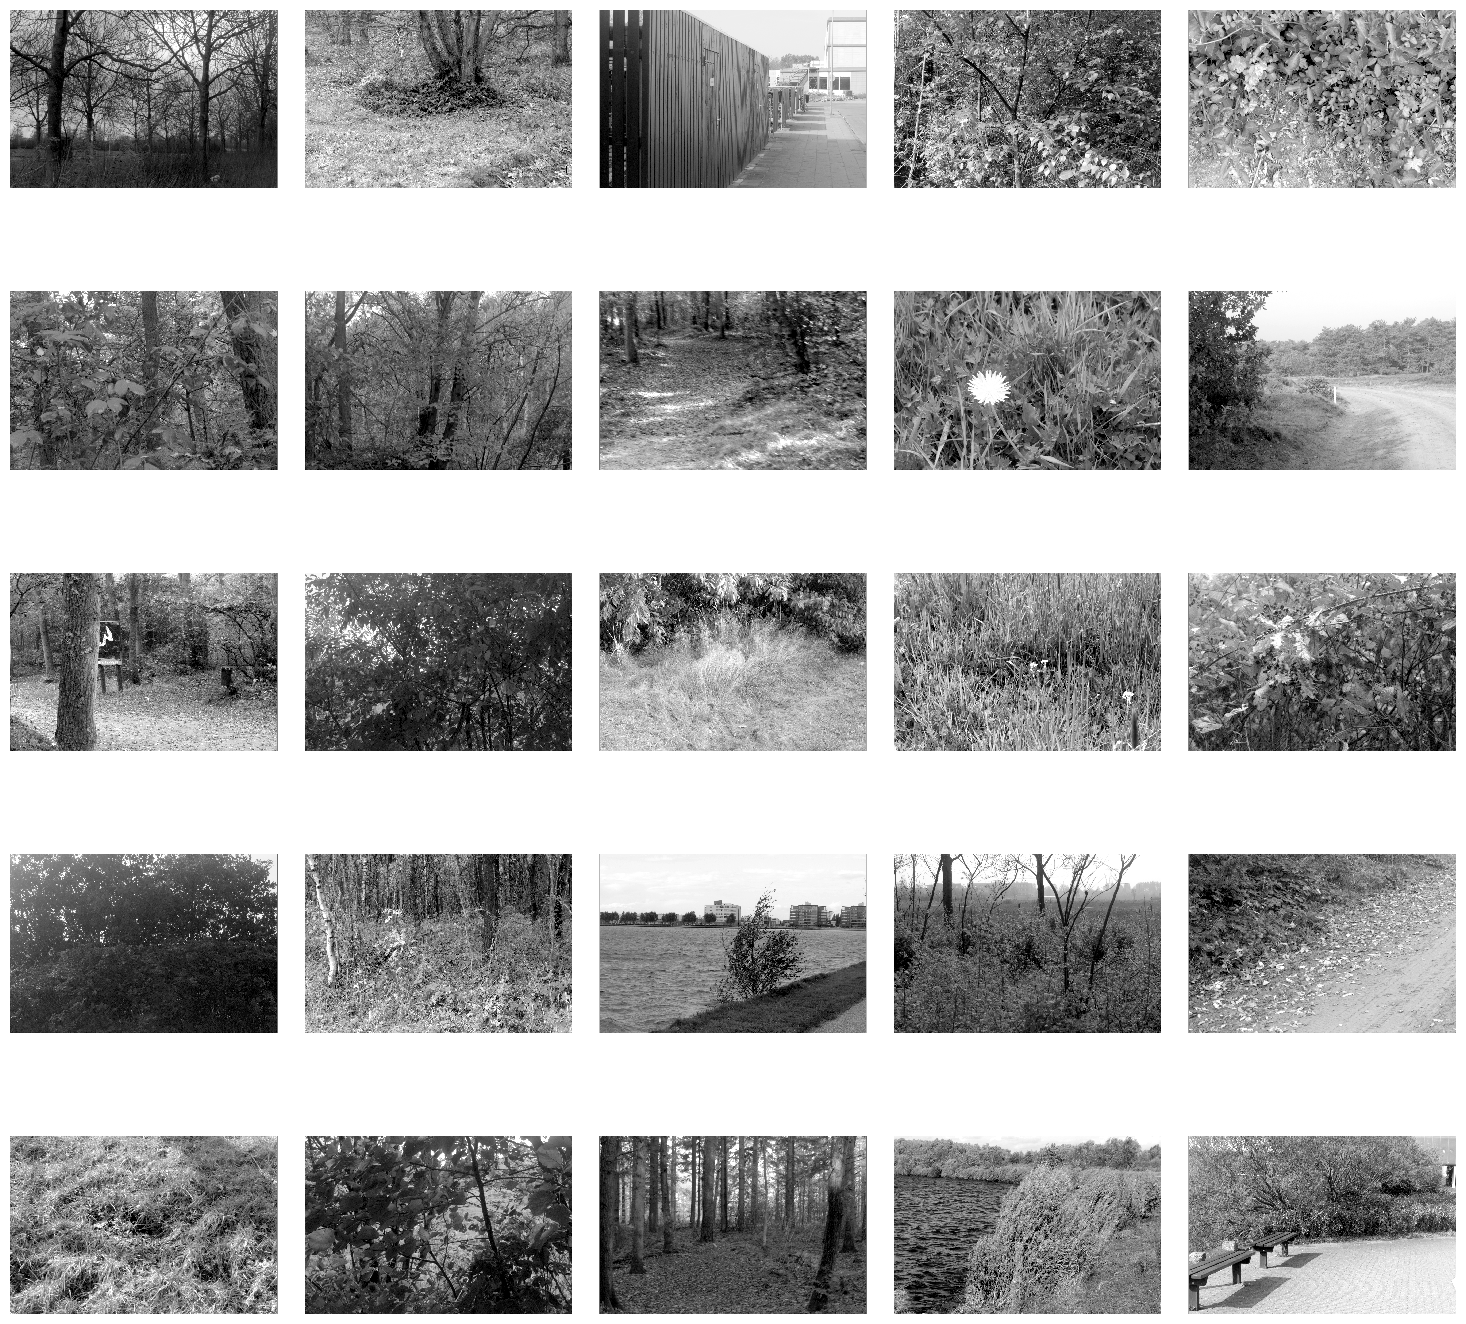

In [7]:
fig, axes = plot_examples(images, 5, 5, random_seed=10, mode="log")

Image dimensions: 1024x1536
x range: -12.80 to 12.80 deg
y range: -8.53 to 8.53 deg


Text(0, 0.5, 'Elevation (deg)')

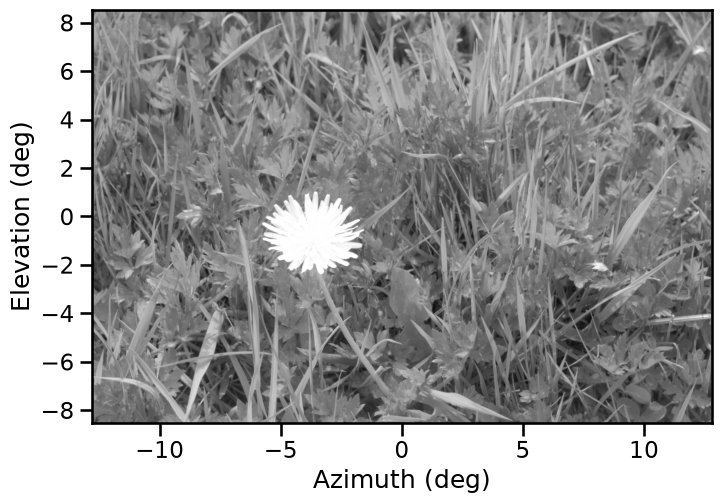

In [8]:
H,W = images.shape[1:3]

print(f"Image dimensions: {H}x{W}")
x_min = -0.5 * W * DPP
x_max =  0.5 * W * DPP
y_min = -0.5 * H * DPP
y_max =  0.5 * H * DPP

print(f"x range: {x_min:.2f} to {x_max:.2f} deg")
print(f"y range: {y_min:.2f} to {y_max:.2f} deg")

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
img = axes.imshow(images[0], cmap="gray", extent=[x_min, x_max, y_min, y_max])
axes.set_xlabel("Azimuth (deg)")
axes.set_ylabel("Elevation (deg)")


## Fly sampling

Similarly to `flyvis`, we will assert that the fly's ommatidia is 13pixels using a box mean or gaussianfilter.
    
*Note:*  this is the same number we get by using Meyer's dataset, so I believe that's how they compute it.

Text(0.5, 1.0, '30x30 receptors')

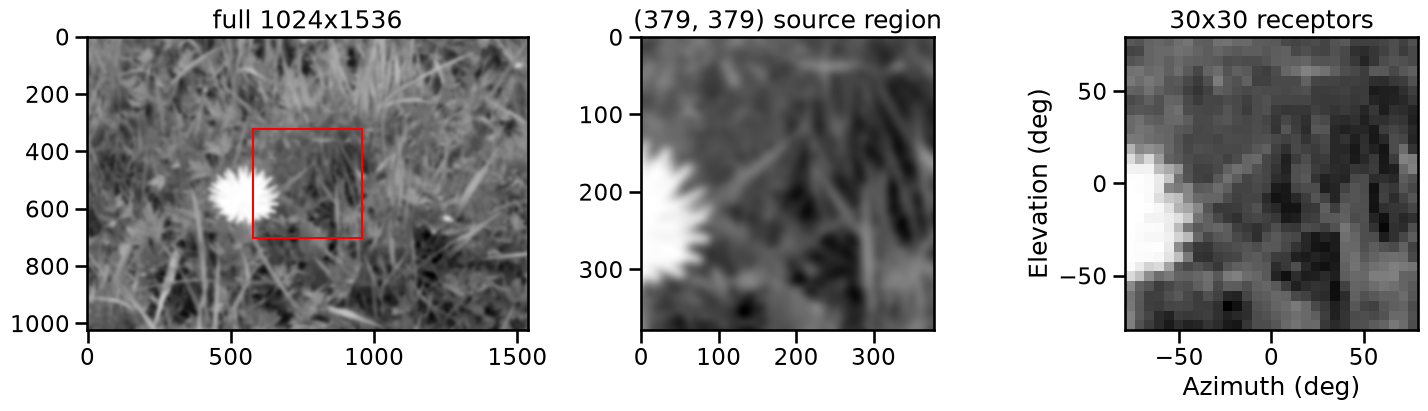

In [9]:
from scipy.ndimage import gaussian_filter

KERNEL_SIZE = 13
EYE_SIZE    = 30 # Number of receptors   
THETA       = 5.3 #Half the angle of view of the eye in degrees
DPP_FLY     = THETA/KERNEL_SIZE #Our resampling dpp
DELTA_RHO_PX = KERNEL_SIZE * 1.08          # Δρ/Δφ ≈ 1.08 → 14.04 px FWHM
SIGMA        = DELTA_RHO_PX / 2.3548   # ≈ 5.96


img         = images[0]
# blur        = uniform_filter(img, size=KERNEL_SIZE)
blur        = gaussian_filter(img, sigma=SIGMA, mode="reflect", truncate=3.0)
coeffs      = spline_filter(blur, order=3, output=np.float32) #spline filter the image to get the coefficients for interpolation, avoids aliasing artifacts

#receptor grid, cartesian for now (source px), centered on 0 
off         = (np.arange(EYE_SIZE) - (EYE_SIZE-1)/2) * KERNEL_SIZE 
gy, gx      = np.meshgrid(off, off, indexing="ij")
cx, cy      = W/2, H/2  #center of the eye in degrees

frame = map_coordinates(coeffs, [gy + cy, gx + cx], order=3,
                        mode="reflect", prefilter=False) #interpolate the image at the receptor locations

# --- crop bounds, per axis --------------------------------------
half_px  = (EYE_SIZE - 1) / 2 * KERNEL_SIZE                      
y0, y1   = int(np.floor(cy - half_px)), int(np.ceil(cy + half_px)) + 1
x0, x1   = int(np.floor(cx - half_px)), int(np.ceil(cx + half_px)) + 1

crop     = blur[y0:y1, x0:x1]

fig, axs = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
axs[0].imshow(blur, cmap="gray")
axs[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                               ec="r", fc="none", lw=1.5))
axs[0].set_title("full 1024x1536")

axs[1].imshow(crop, cmap="gray")
axs[1].set_title(f"{crop.shape} source region")

half = (EYE_SIZE - 1) / 2 * THETA + THETA / 2                   

axs[2].imshow(frame, cmap="gray", interpolation="nearest",
              extent=[-half, half, -half, half])
axs[2].set_xlabel("Azimuth (deg)")
axs[2].set_ylabel("Elevation (deg)")
axs[2].set_title(f"{EYE_SIZE}x{EYE_SIZE} receptors")



## Build naturilistic movie

In [ ]:
d = GetNaturalMovies(DATA_PATH, n_images=N_IMAGES, start_jitter=100,
                     frames_per_segment=75*2, vel_std_deg_s=(120, 70))
for i in range(100):
    d[i]
print(f"acceptance {100 * d.acceptance_rate:.0f}%")

Found 4167 .iml in /home/guardomayas/NUIN/van_hateren/vanhateren_iml; loading batch 0 (30 images).


/tmp/ipykernel_200221/1314142635.py:1: RuntimeWarning: excursion budget is tight on x: limit 475 px is 1.6 sigma of the position spread (293 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 150), or start_jitter (now 100).
  d = GetNaturalMovies(DATA_PATH, batch_size=30, start_jitter=100,
/tmp/ipykernel_200221/1314142635.py:1: RuntimeWarning: excursion budget is tight on y: limit 219 px is 1.3 sigma of the position spread (171 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 150), or start_jitter (now 100).
  d = GetNaturalMovies(DATA_PATH, batch_size=30, start_jitter=100,
/tmp/ipykernel_200221/1314142635.py:4: RuntimeWarning: acceptance rate 72% over 50 samples (69 draws): traces are leaving the scene bounds often, so p(v) is truncated well inside its tails and sampling is 1.4x slower than needed. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (

acceptance 71%


In [12]:
v = np.concatenate([d[i]["vel_deg_s"].numpy()[d.gray_frames:]
                    for i in range(len(d))])
print(v.std(0))

[113.83033   63.770027]


In [14]:
# from IPython.display import HTML, display
# for idx in (0, 5):
#     anim = animate_sample(d, idx=idx, stride=3)
#     display(HTML(anim.to_jshtml()))
#     plt.close(anim._fig)          # suppress the static figure